# Memory Usage Analysis Across Workflows and Datasets

This notebook analyzes memory usage of configurations across different 
workflow-dataset combinations. We compute:
- Percentiles (90th, 95th, max) for successful runs
- Boxplot statistics for runs with anticipated memory exceeding a threshold
- Percentages of failed configurations

**Note:** You need to first run the `python -m experiments.debugging.download_data` script to download the data.

In [ ]:
from pathlib import Path
from typing import List, Tuple
import pandas as pd
import numpy as np
import itertools as it
import math
import matplotlib.pyplot as plt
from lcdb import ResultSet
from tqdm import tqdm

WORKFLOW_CLASSES = [
    "lcdb.workflow.sklearn.KNNWorkflow"
]

# IO paths
DATA_DIR = Path("./data")
OUTPUT_DIR = DATA_DIR / "memory_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COMBINED_P90 = OUTPUT_DIR / "p90_memory_by_workflow_dataset.csv"
COMBINED_BINS = OUTPUT_DIR / "memory_bins_all_workflows.csv"
SUCCESSFUL_STATS = OUTPUT_DIR / "successful_memory_stats.csv"
ANTICIPATED_STATS = OUTPUT_DIR / "anticipated_memory_stats.csv"

# Node / core layout (Surf Snellius -- Genoa partition)
NODE_MEM_GB = 336.0
NODE_CORES = 192

# Binning baseline
BASELINE_MIN_GB = 1.7    # ≤1.7 = full-node bin
INCLUDE_ANTICIPATED_ERRORS = True

In [2]:
def ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)

def load_workflow_results(wf: str, data_dir: Path) -> ResultSet:
    f = data_dir / f"{wf}.jsonl"
    if not f.exists():
        print(f"[WARN] Missing CSV for workflow: {wf} (expected {f})")
        return None
    rs = ResultSet.read_jsonl(f)
    return rs

In [3]:
# 1) Load all workflow CSVs
dfs = [load_workflow_results(wf, DATA_DIR) for wf in WORKFLOW_CLASSES]
dfs = [d for d in dfs if d is not None and not d.empty]
if not dfs:
    raise FileNotFoundError("No workflow CSVs found in DATA_DIR.")
rs = ResultSet.concat(dfs)

In [4]:
def get_df_with_memory_stats_per_dataset_workflow_combination(rs: ResultSet) -> pd.DataFrame:

    rows = []
    for workflow, rs_workflow in rs.group_by_workflow():
        for openmlid, rs_dataset in rs_workflow.group_by_dataset():

            # raw runtimes and memory peaks of all runs for this dataset/workflow combination
            runtimes = np.array([row["experiment_metadata"]["timestamp_end"] - row["experiment_metadata"]["timestamp_start"] for row in rs_dataset])
            memory_peaks = np.array([row["memory_max"] / 1024**3 for row in rs_dataset])
            memory_kills_anticipated = np.array([row["anticipated memory overflow"] for row in rs_dataset])
            memory_kills_executed = np.array(["error" in row and row["error"] is not None and row["error"] == "F_memory_limit_exceeded" for row in rs_dataset])
            anticipated_memory_requirement = np.array([row["anticipated_memory"] for row in rs_dataset])
            
            # determine memory limit
            configured_memory_limits = [r["memory_limit"] for r in rs_dataset if "memory_limit" in r and r["memory_limit"] is not None]
            if configured_memory_limits:
                assert min(configured_memory_limits) == max(configured_memory_limits)
                memory_limit = min(configured_memory_limits)
            else:
                memory_limit = np.nan
            configured_memory_limit = memory_limit / 1024**3

            # determine memory used on average for loading the data
            used_memory_for_data_loading = np.round(np.mean([row["memory_data"] for row in rs_dataset if "memory_data" in row and row["memory_data"] is not None]), 2)

            # summary statistics
            memory_mean_usage = np.round(np.mean(memory_peaks), 2)
            max_memory_peak = np.round(np.max(memory_peaks), 2)
            anticipated_memory_requirement = [v for v in anticipated_memory_requirement if v is not None]
            max_foreseen_memory_peak = np.round(max(max_memory_peak, max(anticipated_memory_requirement) if anticipated_memory_requirement else 0), 2)
            frac_memory_killed = np.mean(memory_kills_executed)
            frac_anticipated_memory_issue = np.mean(memory_kills_anticipated)

            # append the row to output dataframe
            rows.append([workflow, openmlid, runtimes, memory_peaks, memory_kills_anticipated, memory_kills_executed, anticipated_memory_requirement, configured_memory_limit, used_memory_for_data_loading, memory_mean_usage, max_memory_peak, max_foreseen_memory_peak, frac_anticipated_memory_issue, frac_memory_killed])
    
    # return dataframe
    return pd.DataFrame(rows, columns=["workflow", "openmlid", "runtimes", "memory_peaks", "memory kills anticipated", "memory kills executed", "anticipated memory requirement", "memory limit", "memory data", "memory mean peak", "memory max peak", "memory max foreseen peak", "avg num memory kills anticipated", "avg num memory kills executed"])

df = get_df_with_memory_stats_per_dataset_workflow_combination(rs)
df

,workflow,openmlid,runtimes,memory_peaks,memory kills anticipated,memory kills executed,anticipated memory requirement,memory limit,memory data,memory mean peak,memory max peak,memory max foreseen peak,avg num memory kills anticipated,avg num memory kills executed
0,lcdb.workflow.sklearn.KNNWorkflow,3,"[12.152787208557129, 4.378344297409058, 141.76...","[0.3287391662597656, 0.4611854553222656, 0.403...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",[],2.0,0.10,0.41,0.60,0.60,0.00,0.00
1,lcdb.workflow.sklearn.KNNWorkflow,12,"[5.669684171676636, 6.269850969314575, 6.47008...","[0.409210205078125, 0.38687896728515625, 0.376...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",[],21.0,0.10,0.82,4.50,4.50,0.00,0.00
2,lcdb.workflow.sklearn.KNNWorkflow,23,"[2.6237831115722656, 2.538283109664917, 2.5966...","[0.34203338623046875, 0.320526123046875, 0.316...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",[],2.0,0.10,0.33,0.39,0.39,0.00,0.00
3,lcdb.workflow.sklearn.KNNWorkflow,31,"[2.058866262435913, 2.1822316646575928, 2.1515...","[0.3272552490234375, 0.32834625244140625, 0.31...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",[],2.0,0.10,0.34,0.56,0.56,0.00,0.00
4,lcdb.workflow.sklearn.KNNWorkflow,54,"[2.2366113662719727, 2.4369866847991943, 2.420...","[0.3305778503417969, 0.324127197265625, 0.3179...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",[],2.0,0.10,0.33,0.35,0.35,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,lcdb.workflow.sklearn.KNNWorkflow,42734,"[12.984734773635864, 13.588777780532837, 15.58...","[0.505889892578125, 0.4171142578125, 0.5155944...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",[22.253],21.0,0.10,4.98,44.63,44.63,0.01,0.04
67,lcdb.workflow.sklearn.KNNWorkflow,42742,"[63.56217169761658, 135.54657554626465, 154.11...","[9.432498931884766, 2.7945899963378906, 5.7002...","[True, False, False, False, False, False, Fals...","[False, False, True, False, False, False, Fals...",[8.0],5.0,0.71,3.46,9.43,9.43,0.01,0.16
68,lcdb.workflow.sklearn.KNNWorkflow,42746,"[229.5332624912262, 361.1002905368805, 250.001...","[9.077709197998047, 9.172054290771484, 10.9209...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",[],67.0,5.04,11.85,71.92,71.92,0.00,0.01
69,lcdb.workflow.sklearn.KNNWorkflow,42769,"[28.72409415245056, 31.155743837356567, 31.445...","[1.8548049926757812, 2.5239181518554688, 2.483...","[False, False, False, False, False, False, Tru...","[False, False, False, False, True, False, Fals...","[32.0, 32.0, 32.0, 32.0]",21.0,0.60,5.54,33.44,33.44,0.04,0.02


# Some Visualization of Memory Consumption

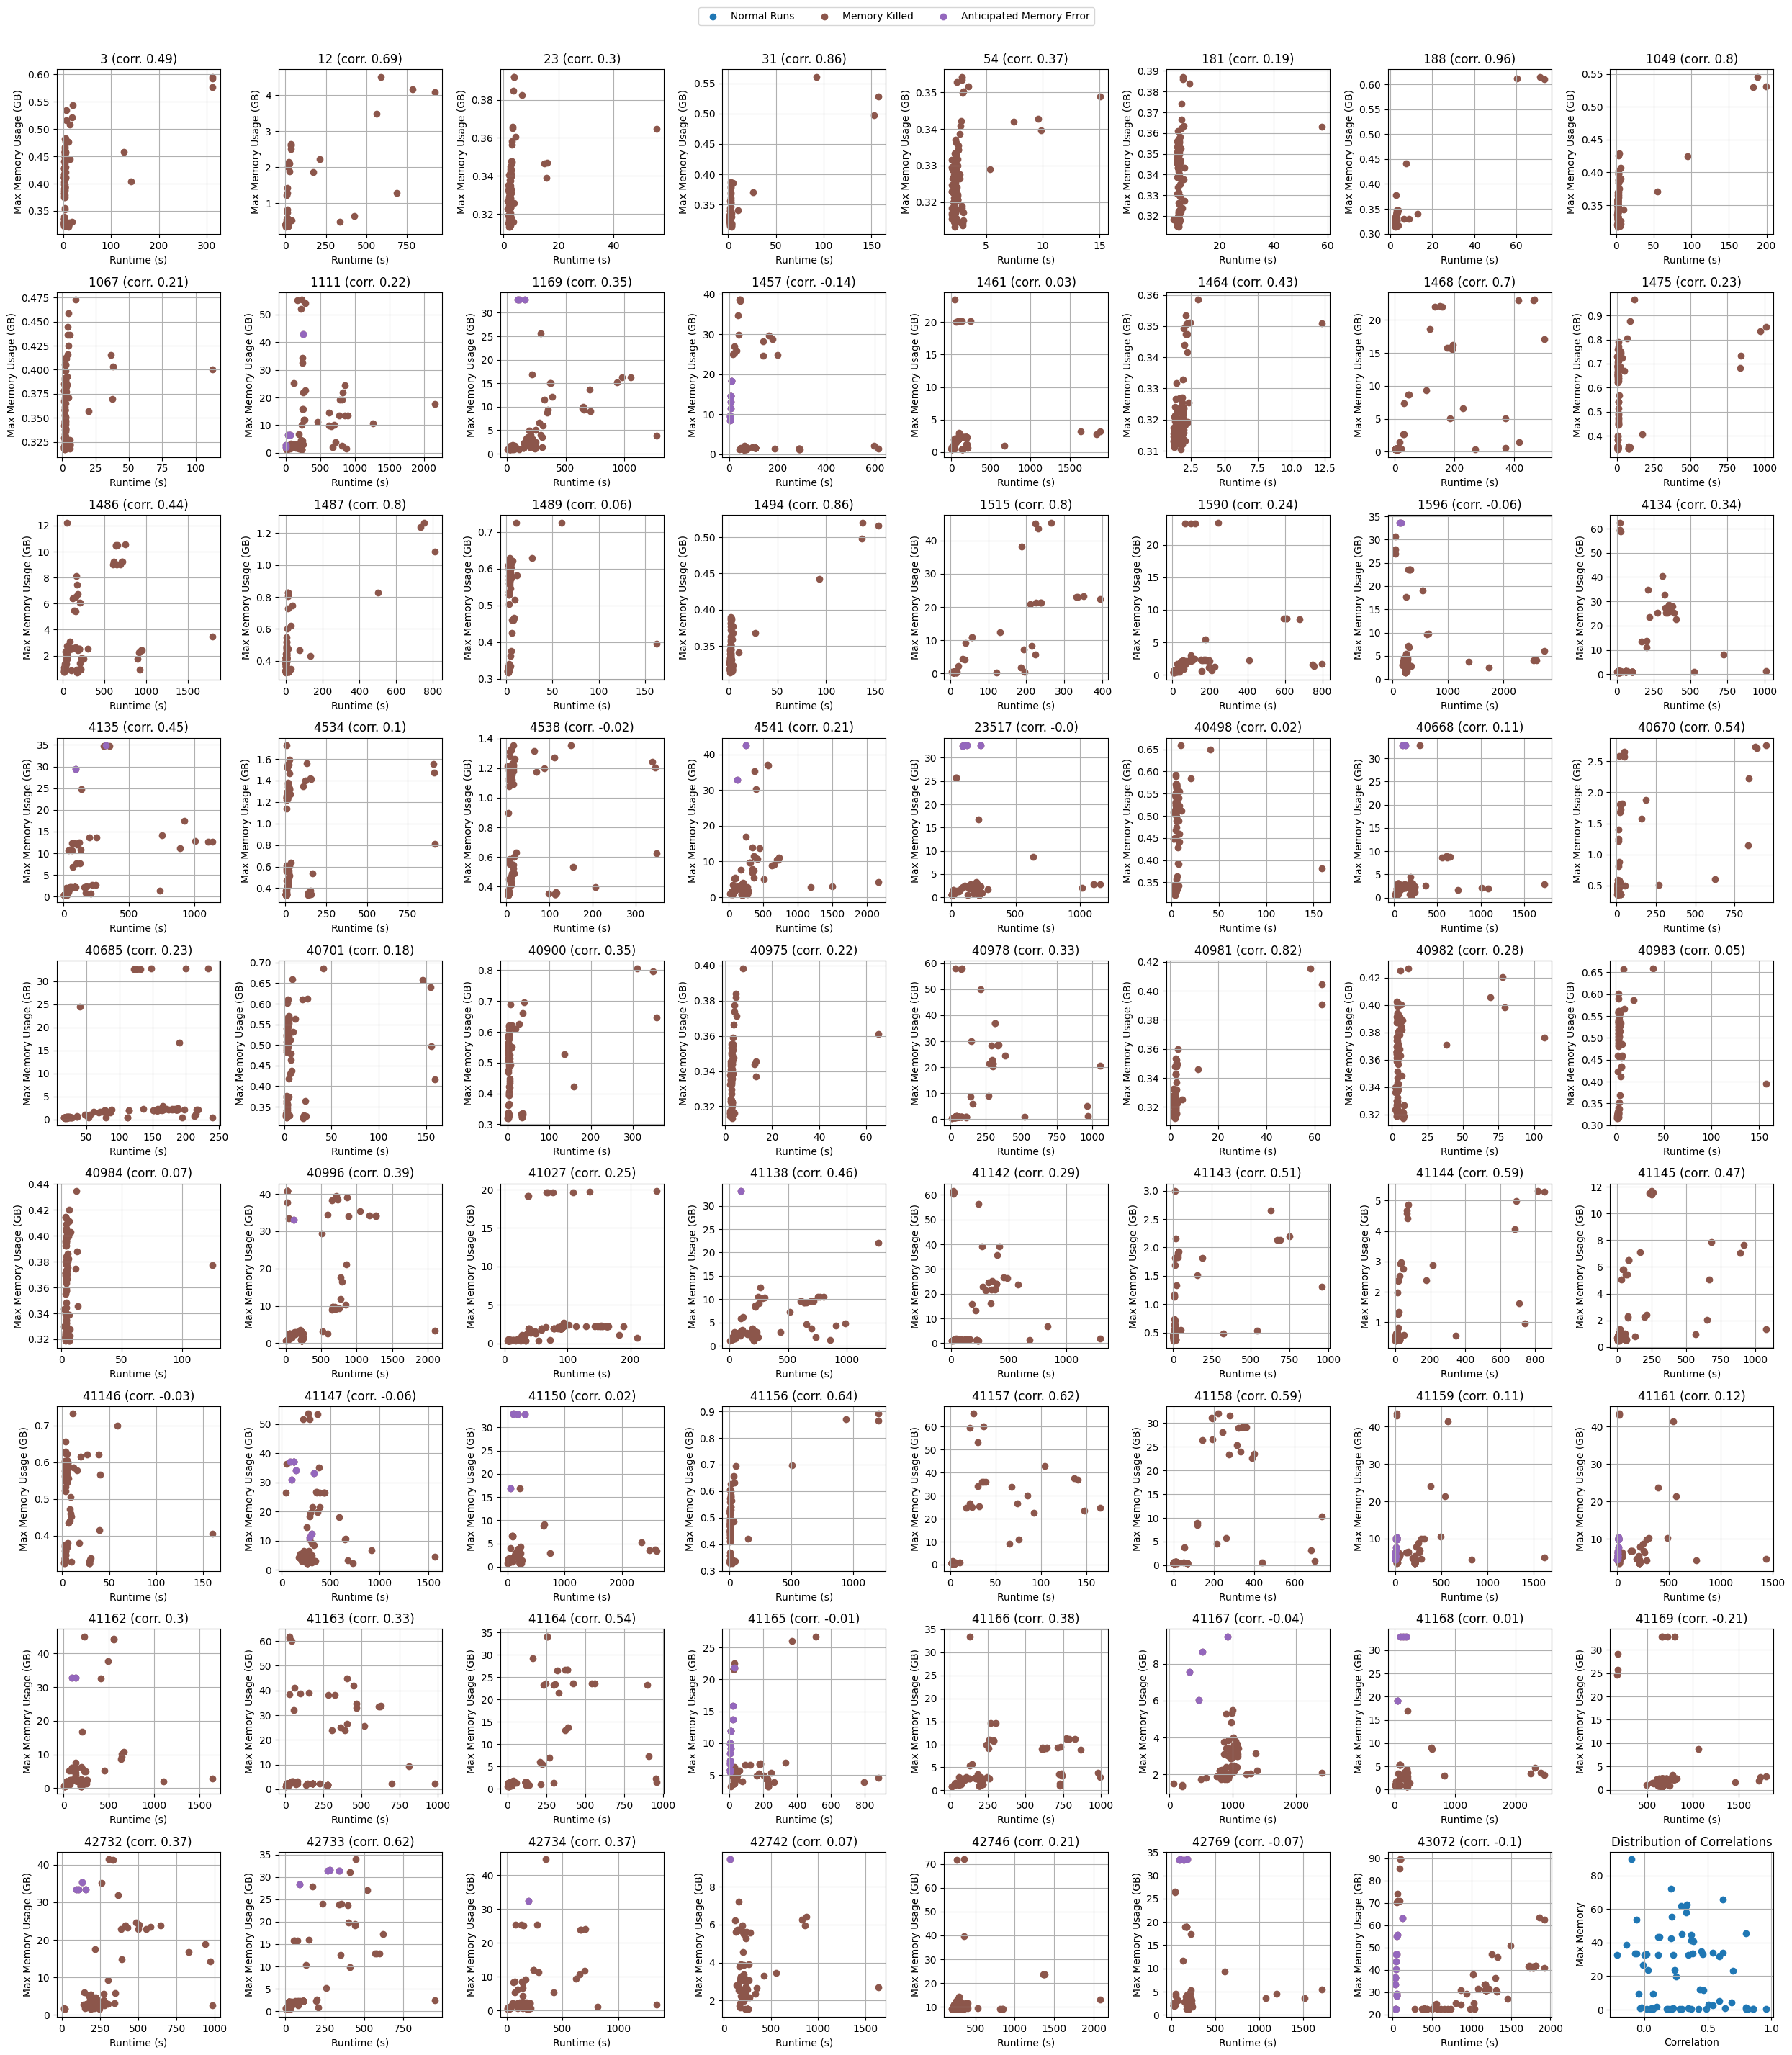

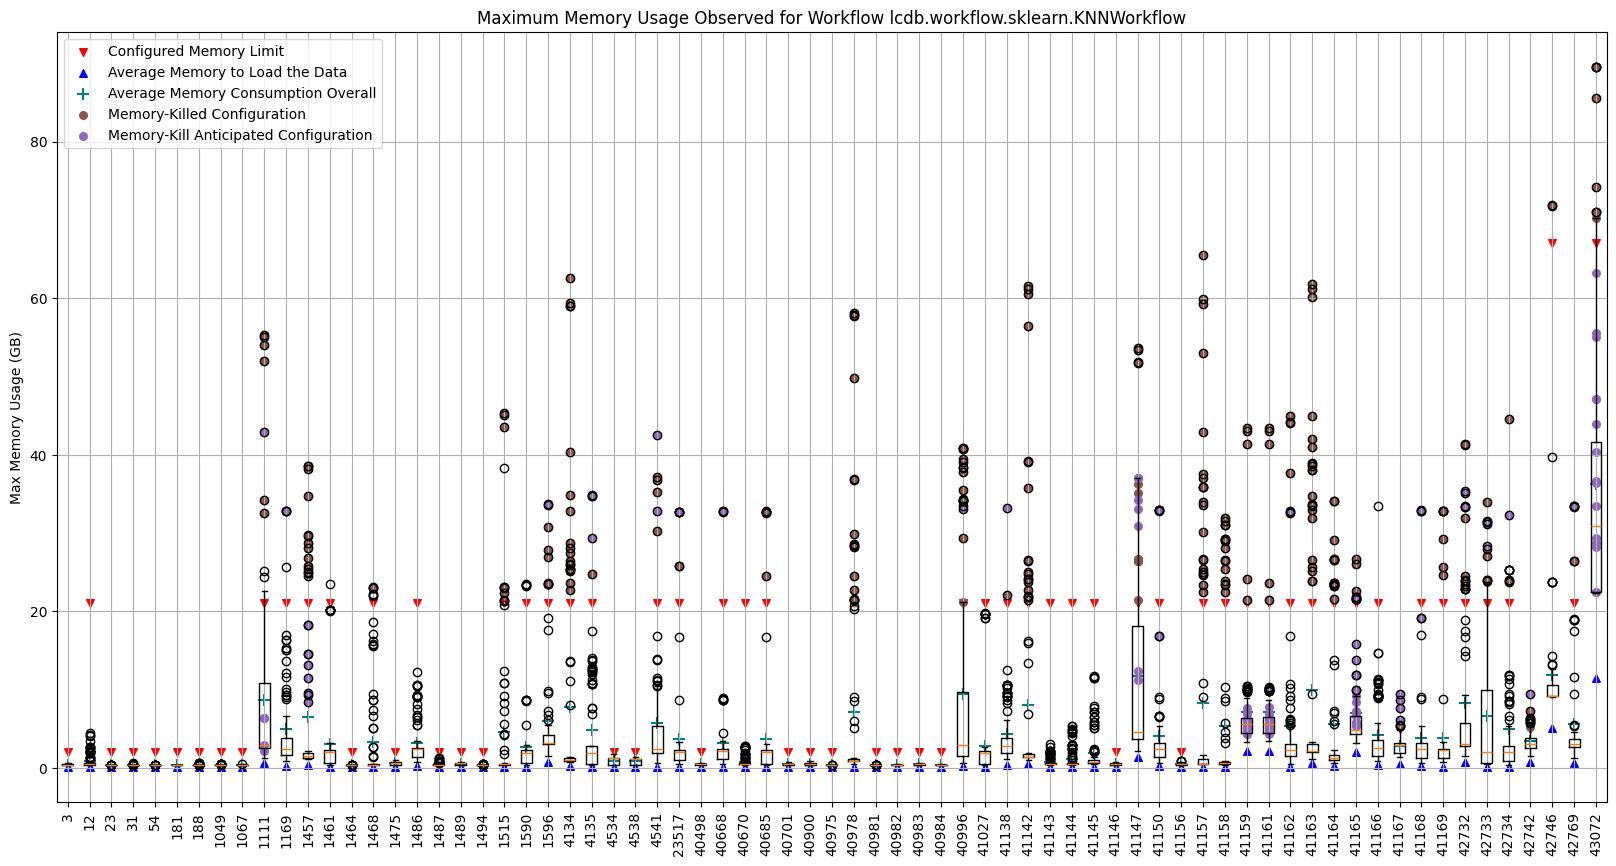

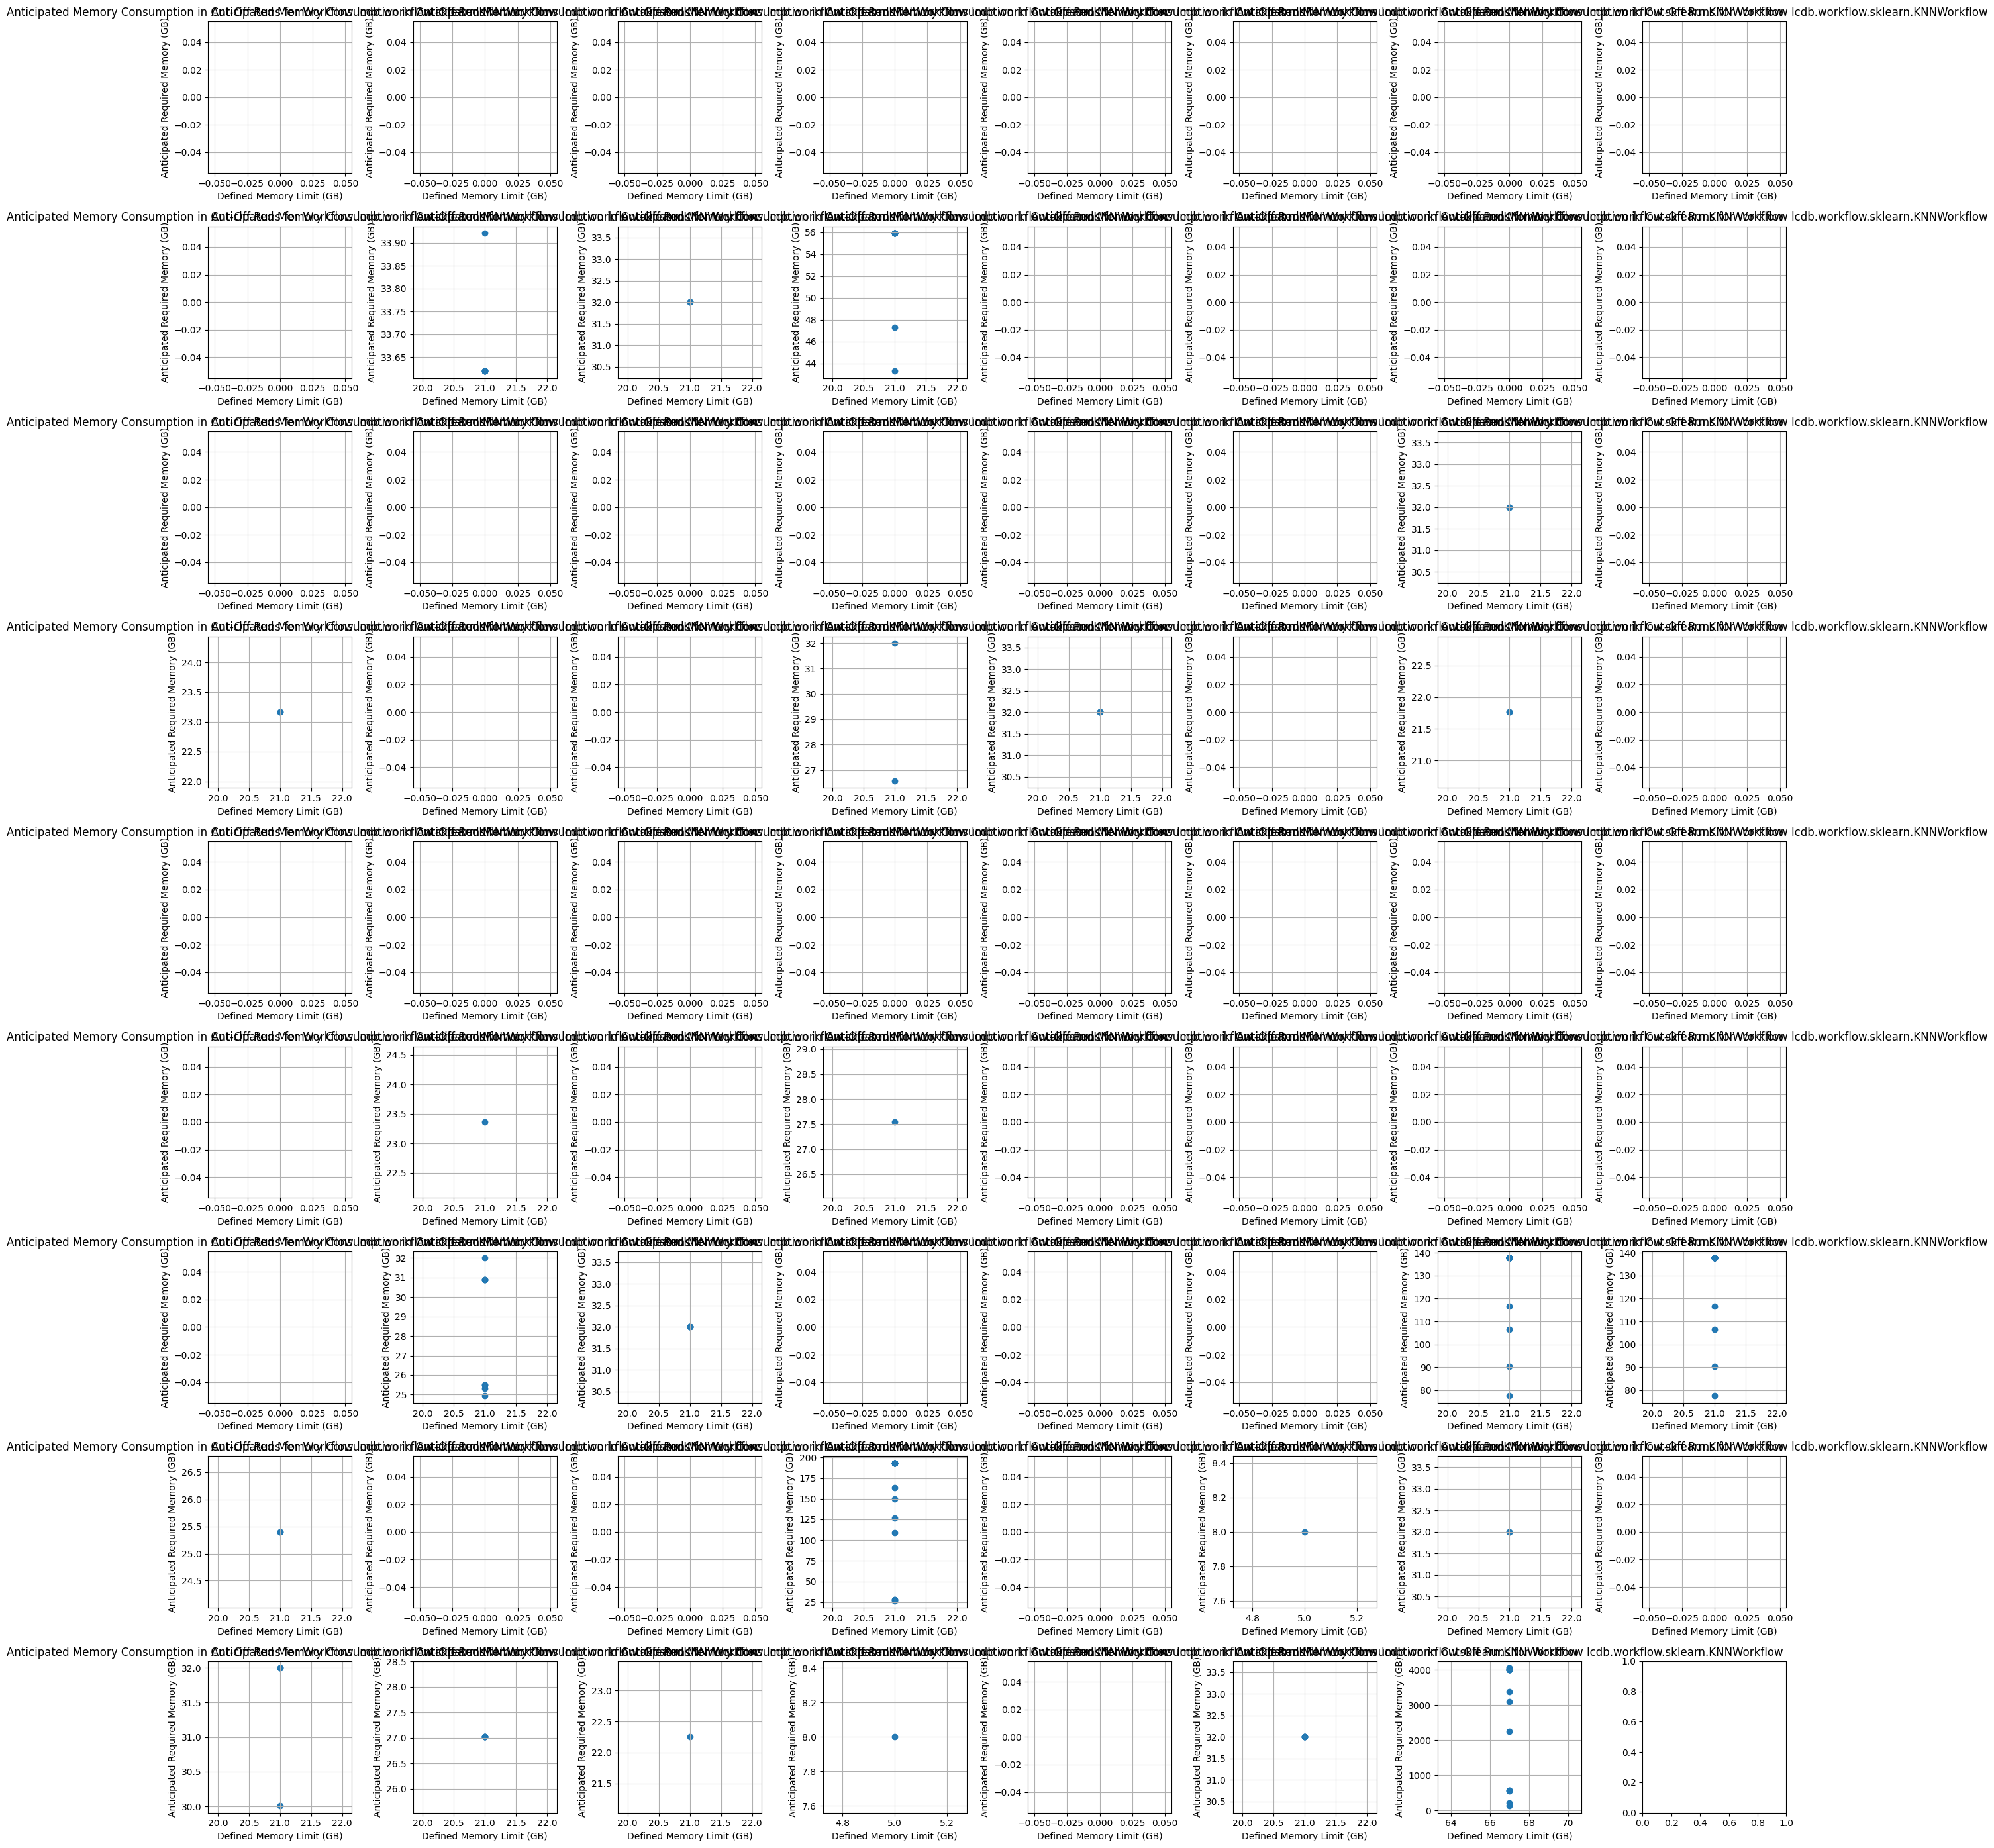

In [5]:
def plot_memory_vs_runtimes(df, n_cols=8):
    datasets = sorted(df["openmlid"].unique())
    for workflow, df_workflow in df.groupby("workflow"):
        
        correlations = []
        max_memory = []
        n_rows = int(np.ceil(len(datasets) / n_cols))
        fig, axs = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols + 1, 3 * n_rows + 1))
        for ax, (openmlid, df_dataset) in zip(axs.flatten(), df_workflow.groupby("openmlid")):
            df_dataset = df_dataset.iloc[0]
            
            runtimes = df_dataset["runtimes"]
            memory = df_dataset["memory_peaks"]

            mask2 = df_dataset["memory kills anticipated"]
            mask1 = np.ones_like(mask2)#(~mask2 & np.array(["error" in row and row["error"] is not None and "memory" in row["error"].lower() for row in df_dataset]))
            no_mask = ~(mask1 | mask2)
            ax.scatter(runtimes[no_mask], memory[no_mask], label="Normal Runs")
            if np.count_nonzero(mask1) > 0:
                ax.scatter(runtimes[mask1], memory[mask1], label="Memory Killed", color="C5")
            if np.count_nonzero(mask2) > 0:
                ax.scatter(runtimes[mask2], memory[mask2], label="Anticipated Memory Error", color="C4")
            ax.grid()
            corr = np.round(np.corrcoef(runtimes, memory)[0, 1], 2)
            correlations.append(corr)
            max_memory.append(max(memory))
            ax.set_title(f"{openmlid} (corr. {corr})")
            ax.set_xlabel("Runtime (s)")
            ax.set_ylabel("Max Memory Usage (GB)")

        # show correlation vs max memory consumption. This is to understand whether high correlation is relevant for high memory scenarios
        ax = axs[-1, -1]
        ax.scatter(correlations, max_memory)
        ax.set_xlabel("Correlation")
        ax.set_ylabel("Max Memory")
        ax.set_title("Distribution of Correlations")
        ax.grid()

        handles, labels = axs[-1, -2].get_legend_handles_labels()
        fig.legend(handles, labels, bbox_to_anchor=(0.5, 1.02), loc='upper center', ncol=3)
        fig.tight_layout()
        plt.show()


def plot_memory_consumption(df):
    for workflow, df_workflow in df.groupby("workflow"):

        # sort dataframe
        df_workflow = df_workflow.sort_values("openmlid", ascending=True)

        # create figure object
        fig, ax = plt.subplots(figsize=(20, 10))

        # create visual elements per dataset
        ax.boxplot(df_workflow["memory_peaks"])
        x_base = 1 + np.arange(len(df_workflow))
        datasets = df_workflow["openmlid"]
        ax.scatter(x_base, df_workflow["memory limit"], marker="v", s=30, color="red", label="Configured Memory Limit")
        ax.scatter(x_base, df_workflow["memory data"], marker="^", s=30, color="blue", label="Average Memory to Load the Data")
        ax.scatter(x_base, df_workflow["memory mean peak"], marker="+", s=70, color="teal", label="Average Memory Consumption Overall")

        for i, openmlid in zip(x_base, datasets):
            df_dataset = df_workflow[df_workflow["openmlid"] == openmlid].iloc[0]
            killed_configs_on_dataset = df_dataset["memory kills executed"]
            kill_anticipated_configs_on_dataset = df_dataset["memory kills anticipated"]
            ax.scatter(np.count_nonzero(killed_configs_on_dataset) * [i], df_dataset["memory_peaks"][killed_configs_on_dataset], marker="o", s=30, color="C5", label="Memory-Killed Configuration" if i == 1 else None)
            ax.scatter(np.count_nonzero(kill_anticipated_configs_on_dataset) * [i], df_dataset["memory_peaks"][kill_anticipated_configs_on_dataset], marker="o", s=30, color="C4", label="Memory-Kill Anticipated Configuration" if i == 1 else None)

        ax.set_xticks(x_base)
        ax.set_xticklabels(df_workflow["openmlid"], rotation=90)
        ax.set_ylabel("Max Memory Usage (GB)")
        ax.set_title(f"Maximum Memory Usage Observed for Workflow {workflow}")

        # create visual aid elements
        ax.grid()
        ax.legend()

        # show figure
        plt.show()

def plot_anticipated_memory_requirements(df, n_cols=8):
    
    datasets = sorted(df["openmlid"].unique())
    for workflow, df_workflow in df.groupby("workflow"):

        n_rows = int(np.ceil(len(df["openmlid"]) / n_cols))
        fig, axs = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols + 1, 3 * n_rows + 1))
        for ax, (openmlid, df_dataset) in zip(axs.flatten(), df.groupby("openmlid")):
            row = df_dataset.iloc[0]
            ax.scatter(len(row["anticipated memory requirement"]) * [row["memory limit"]], row["anticipated memory requirement"])
            ax.set_xlabel("Defined Memory Limit (GB)")
            ax.set_ylabel("Anticipated Required Memory (GB)")
            ax.set_title(f"Anticipated Memory Consumption in Cut-Off Runs for Workflow {workflow}")
            ax.grid()
        fig.tight_layout()
        plt.show()

plot_memory_vs_runtimes(df)
plot_memory_consumption(df)
plot_anticipated_memory_requirements(df)

# Determine Number of Parallel Tasks per Node

## Approach 1: Weighted Sampling-Based Assignments

In [6]:
class TaskParallelizationEstimator:

    def __init__(self, df, absolute_memory_limit_per_node, absolute_memory_limit_per_config):
        self.df = df
        self.absolute_memory_limit_per_node = absolute_memory_limit_per_node
        self.absolute_memory_limit_per_config = absolute_memory_limit_per_config

        # compute maximally conservative theoretical limit
        self.parallel_task_assignments = {
            "most_conservative": {
                "name": "Maximally Conservative (from hardware)",
                "values": len(df) * [max(1, int(self.absolute_memory_limit_per_node // self.absolute_memory_limit_per_config))]
            }
        }

    @property
    def df_most_conservative(self):
        return self._df_most_conservative
    
    def compute_conservative_number_of_parallel_tasks_for_exclusive_nodes_based_on_max_observed_memory_consumption(
        self,
        use_forseen_peaks=False
    ):
        key = f"conservative_from_data_{use_forseen_peaks}"
        if key not in self.parallel_task_assignments:
            col = []
            for _, row in self.df.iterrows():

                # determine the maximum number of cores that can be used in parallel
                max_peak_per_config = min(self.absolute_memory_limit_per_config, row["memory max foreseen peak"] if use_forseen_peaks else row["memory max peak"])
                num_jobs_possible_with_max_consume = int(self.absolute_memory_limit_per_node // max_peak_per_config)

                col.append(num_jobs_possible_with_max_consume)
            
            self.parallel_task_assignments[key] = {
                "name": "Conservative From Data",
                "values": np.array(col)
            }
    
    def compute_number_of_parallel_tasks_based_on_average_and_limited_max_for_exclusive_nodes(self,
            num_of_parallel_max_consumers,
            use_forseen_peaks=False
        ):

        key = f"conservative_average_{num_of_parallel_max_consumers}_{use_forseen_peaks}"
        if key not in self.parallel_task_assignments:

            col = []
            for _, row in self.df.iterrows():

                # determine the maximum number of cores that can be used in parallel
                max_peak_per_config = min(self.absolute_memory_limit_per_config, row["memory max foreseen peak"] if use_forseen_peaks else row["memory max peak"])
                memory_after_max_jobs = self.absolute_memory_limit_per_node - num_of_parallel_max_consumers * max_peak_per_config
                num_cores_designated_for_average_consume = memory_after_max_jobs // row["memory mean peak"]
                max_num_cores_theoretically_usable_in_parallel = int(num_cores_designated_for_average_consume + num_of_parallel_max_consumers)

                col.append(max_num_cores_theoretically_usable_in_parallel)
            
            self.parallel_task_assignments[key] = {
                "name": f"Conservative Average (maximally {num_of_parallel_max_consumers} parallel maximum consumers)",
                "values": np.array(col)
            }

    def approximate_parallel_tasks_based_on_sampling(self,
            sample_size=10**4,
            confidence=0.999,
            importance_of_most_expensive_compared_to_cheapest=2
        ):

        def sample_memory_consumptions_for_setup(empirical_memory_peaks, num_parallel_tasks, absolute_limit_per_config, sample_size=10**4, importance_of_most_expensive_compared_to_cheapest=2):
            """
                This function samples memory consumptions that would occur when running `num_parallel_tasks` in parallel where memory peaks are distributed according to `empirical_memory_peaks`, taking into account that we would kill upon usage above `absolute_limit_per_config`.

            Args:
                empirical_memory_peaks (Th): _description_
                num_parallel_tasks (_type_): _description_
                absolute_limit_per_config (_type_): _description_
                sample_size (_type_, optional): _description_. Defaults to 10**4.

            Returns:
                _type_: _description_
            """
            memory_consumptions = []
            memory_peaks_sorted = sorted(empirical_memory_peaks)
            p = np.linspace(1, importance_of_most_expensive_compared_to_cheapest, len(memory_peaks_sorted))
            p /= p.sum()
            for simulated_peaks in np.random.choice(memory_peaks_sorted, replace=True, p=p, size=(sample_size, num_parallel_tasks)):
                memory_consumptions.append(sum(min(absolute_limit_per_config, c) for c in simulated_peaks))
            return np.array(memory_consumptions)

        def get_safe_num_of_parallel_tasks_for_exclusive_node_with_configured_memory_limit(
                empirical_memory_peaks,
                absolute_limit_per_config,
                node_limit,
                importance_of_most_expensive_compared_to_cheapest=2,
                confidence=0.999,
                sample_size=10**4
            ):
            
            last_tried_num = np.inf
            num_parallel_tasks = 10**3
            tried_nums_ok = set([1])
            tried_nums_notok = set()
            while num_parallel_tasks != last_tried_num:

                sampled_overall_memory_peaks = sample_memory_consumptions_for_setup(
                    empirical_memory_peaks=empirical_memory_peaks,
                    num_parallel_tasks=num_parallel_tasks,
                    absolute_limit_per_config=absolute_limit_per_config,
                    sample_size=sample_size,
                    importance_of_most_expensive_compared_to_cheapest=importance_of_most_expensive_compared_to_cheapest
                )
                probability_of_overflow = np.mean(sampled_overall_memory_peaks >= node_limit)
                can_be_increased = probability_of_overflow < 1 - confidence

                # if the configuration is ok but could be increased, seek the next middle-point
                num_parallel_tasks_tried_now = num_parallel_tasks
                if can_be_increased:
                    previously_tried_bigger_nums = [v for v in tried_nums_notok if v > num_parallel_tasks_tried_now]
                    if previously_tried_bigger_nums:
                        num_parallel_tasks = (num_parallel_tasks + min(previously_tried_bigger_nums)) // 2
                    tried_nums_ok.add(num_parallel_tasks_tried_now)

                # if the configuration was not ok, reduce it
                else:
                    previously_tried_ok_smaller_nums = [v for v in tried_nums_ok if v < num_parallel_tasks_tried_now]
                    num_parallel_tasks = (num_parallel_tasks + max(previously_tried_ok_smaller_nums)) // 2
                    tried_nums_notok.add(num_parallel_tasks_tried_now)
                last_tried_num = num_parallel_tasks_tried_now
            return num_parallel_tasks

        key = f"sampled_{sample_size}_{confidence}_{importance_of_most_expensive_compared_to_cheapest}"
        if key not in self.parallel_task_assignments:
            col = []
            pbar = tqdm(total=len(self.df))
            for _, row in self.df.iterrows():
                num_parallel_tasks_theoretic = get_safe_num_of_parallel_tasks_for_exclusive_node_with_configured_memory_limit(
                    row["memory_peaks"],
                    absolute_limit_per_config=self.absolute_memory_limit_per_config,
                    node_limit=self.absolute_memory_limit_per_node,
                    sample_size=sample_size,
                    confidence=confidence,
                    importance_of_most_expensive_compared_to_cheapest=importance_of_most_expensive_compared_to_cheapest
                )
                col.append(num_parallel_tasks_theoretic)
                pbar.update(1)
            pbar.close()
            self.parallel_task_assignments[key] = {
                "name": f"Sampled with confidence {confidence} ({sample_size} samples with weight {importance_of_most_expensive_compared_to_cheapest} for expensive runs)",
                "values": np.array(col)
            }
    
    def get_profile_df(self, profile, available_cpus):
        
        df_profile = self.df[(["workflow"] if "workflow" in self.df.columns else []) + ["openmlid"]].copy()
        df_profile["parallel tasks assigned"] = np.minimum(available_cpus, self.parallel_task_assignments[profile]["values"])
        df_profile["num cores per task"] = available_cpus // df_profile["parallel tasks assigned"]
        df_profile["memory limit per task"] = self.absolute_memory_limit_per_config
        return df_profile


In [7]:
estimator_64 = TaskParallelizationEstimator(df, absolute_memory_limit_per_node=336, absolute_memory_limit_per_config=64)
estimator_64.approximate_parallel_tasks_based_on_sampling(confidence=0.99, sample_size=10**4, importance_of_most_expensive_compared_to_cheapest=2)
estimator_64.compute_conservative_number_of_parallel_tasks_for_exclusive_nodes_based_on_max_observed_memory_consumption(use_forseen_peaks=True)
estimator_64.compute_number_of_parallel_tasks_based_on_average_and_limited_max_for_exclusive_nodes(num_of_parallel_max_consumers=4, use_forseen_peaks=True)

100%|██████████| 71/71 [31:32<00:00, 26.65s/it] 


In [8]:
estimator_128 = TaskParallelizationEstimator(df, absolute_memory_limit_per_node=336, absolute_memory_limit_per_config=128)
estimator_128.approximate_parallel_tasks_based_on_sampling(confidence=0.99, sample_size=10**4, importance_of_most_expensive_compared_to_cheapest=2)
estimator_128.compute_conservative_number_of_parallel_tasks_for_exclusive_nodes_based_on_max_observed_memory_consumption(use_forseen_peaks=True)
estimator_128.compute_number_of_parallel_tasks_based_on_average_and_limited_max_for_exclusive_nodes(num_of_parallel_max_consumers=4, use_forseen_peaks=True)

100%|██████████| 71/71 [28:16<00:00, 23.89s/it] 


In [10]:
estimator_64.get_profile_df(
    profile="sampled_10000_0.99_2",
    available_cpus=192
).to_csv("resource_assignments_64gb_limit_knn.csv", index=False)
estimator_128.get_profile_df(
    profile="sampled_10000_0.99_2",
    available_cpus=192
).to_csv("resource_assignments_128gb_limit_knn.csv", index=False)

# Visualize Parallelization Assignments

In [11]:
def compare_task_parallelization_for_schemes(estimator, approach1, approach2, max_cores):

    data_1 = np.minimum(max_cores, estimator.parallel_task_assignments[approach1]["values"])
    data_2 = np.minimum(max_cores, estimator.parallel_task_assignments[approach2]["values"])
    name1 = estimator.parallel_task_assignments[approach1]["name"]
    name2 = estimator.parallel_task_assignments[approach2]["name"]

    fig, ax_row = plt.subplots(1, 4, figsize=(20, 4))
    ax_row[0].hist(data_1, bins=20, alpha=0.5, label=name1)
    ax_row[0].hist(data_2, bins=20, alpha=0.5, label=name2)
    ax_row[0].set_title(f"Distribution of assigned tasks")
    ax_row[0].set_xlabel("Parallel Tasks")
    ax_row[0].legend()

    
    ax_row[1].boxplot([data_1, data_2])
    ax_row[1].set_xticklabels([name1[:20], name2[:20]])
    ax_row[1].set_title(f"Distribution of assigned tasks")
    ax_row[1].set_ylabel("Parallel Tasks")


    # append configuration
    core_gain_abs = data_1 - data_2
    core_gain_rel = np.round(core_gain_abs / data_1 - 1, 3)

    ax_row[2].boxplot(core_gain_rel * 100)
    ax_row[2].set_title(f"Relative Increase in Parallel Jobs\ncompared to the most conservative scenario")
    ax_row[2].set_ylabel("Increase in Assingable cores (%)")
    ax_row[2].set_xticks([])

    ax_row[3].scatter(data_1, data_2, alpha=0.5)
    ax_row[3].set_title(f"Efficient vs most conservative assignment")
    ax_row[3].set_xlabel(name1)
    ax_row[3].set_ylabel(name2)
    ax_row[3].plot([0, 192], [0, 192], linestyle="--", color="black")
    ax_row[3].grid()
    fig.tight_layout()
    plt.show()

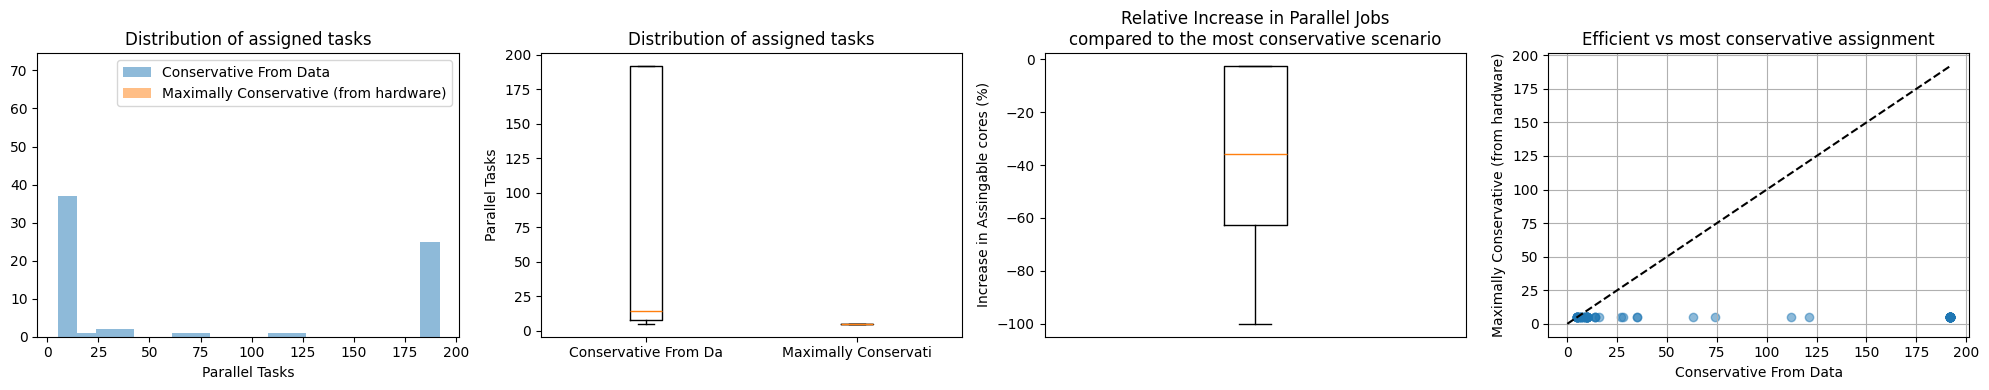

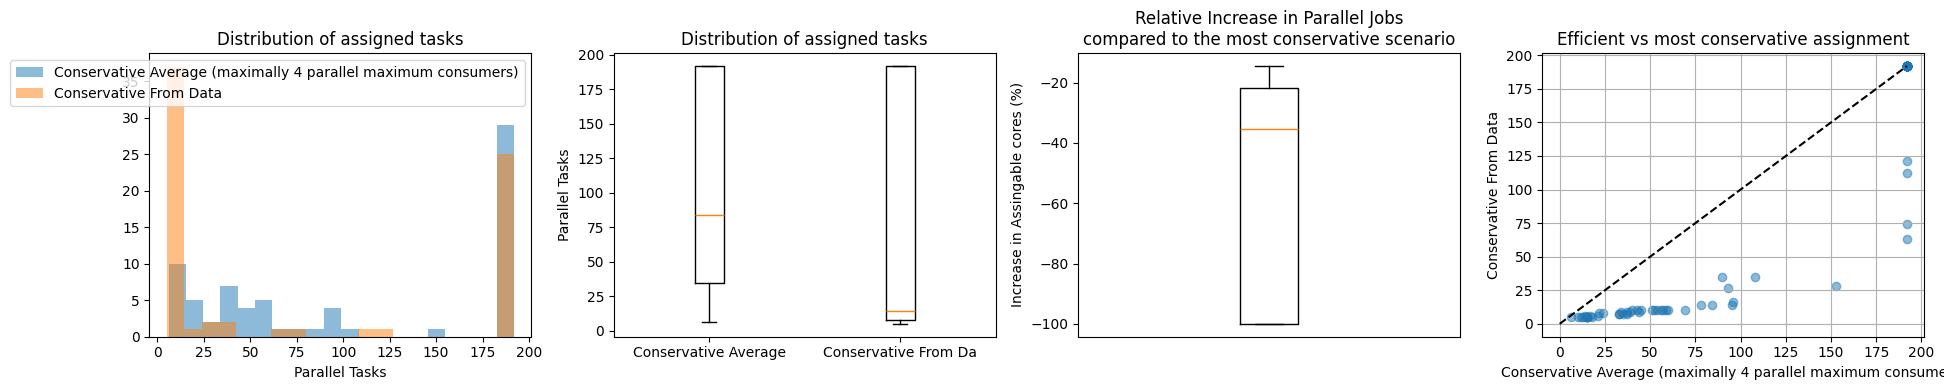

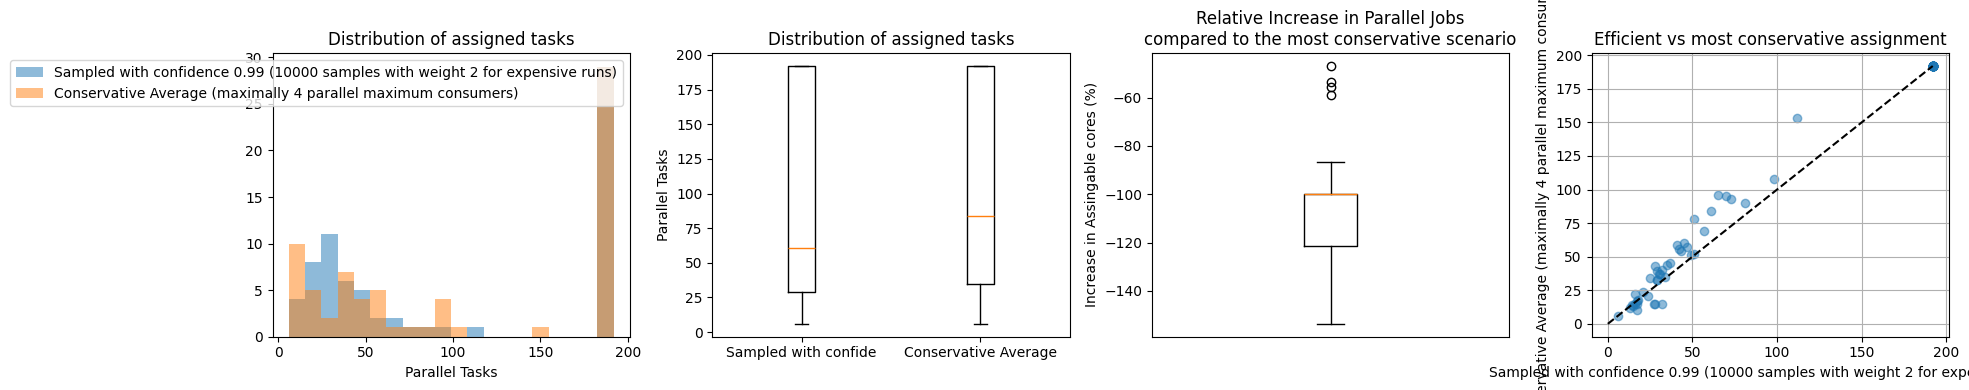

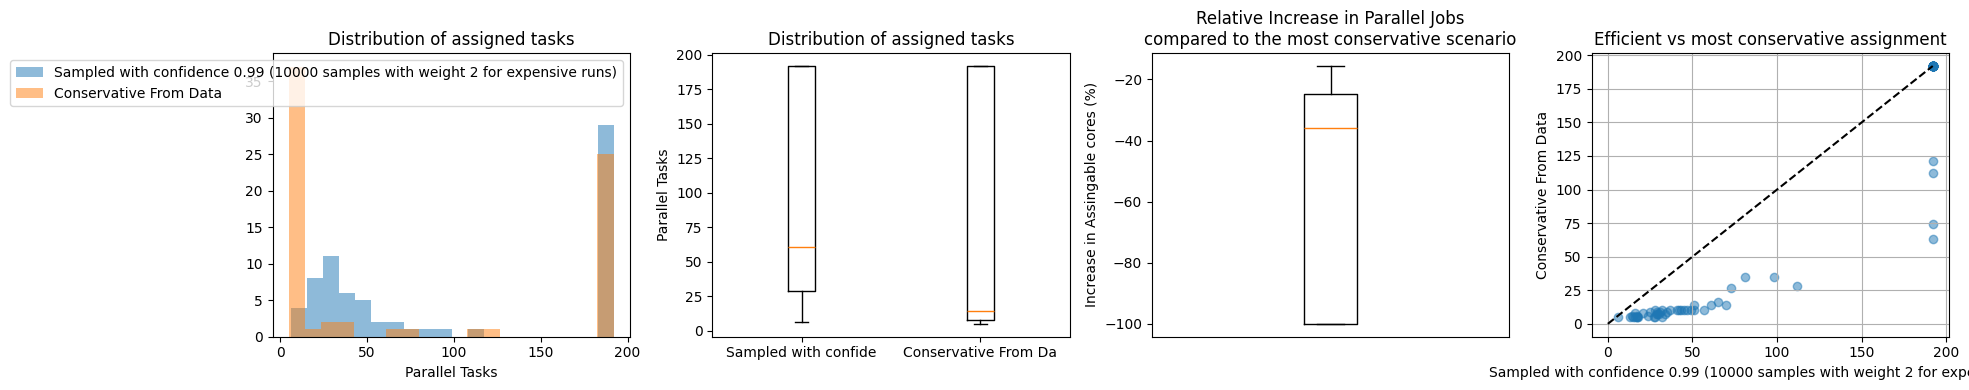

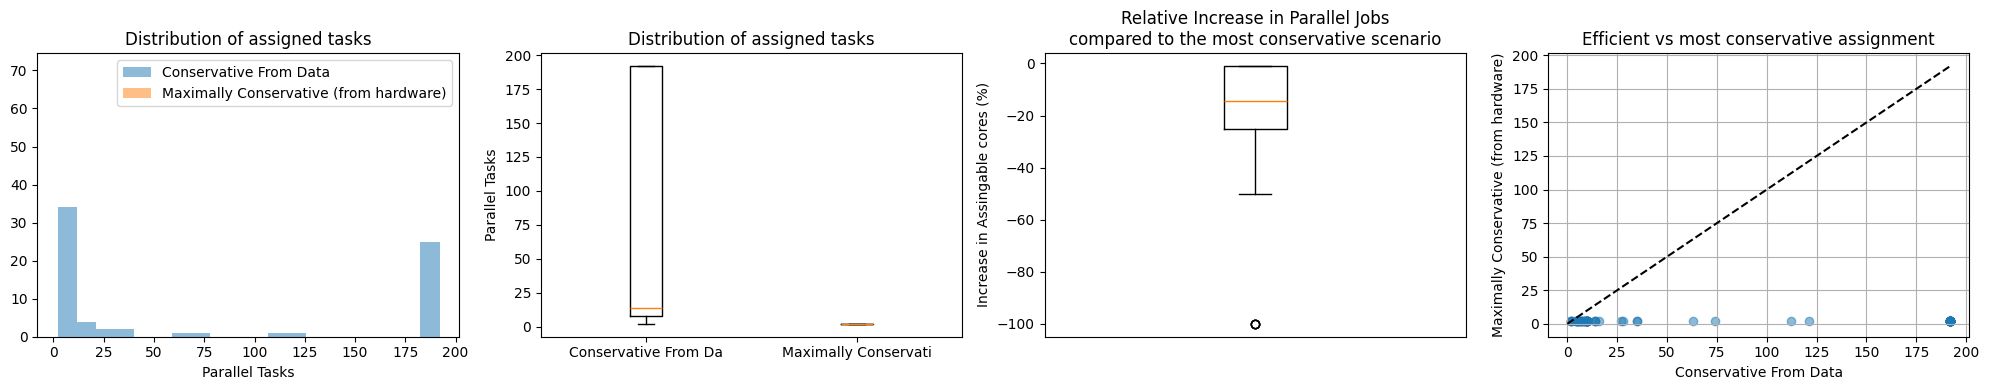

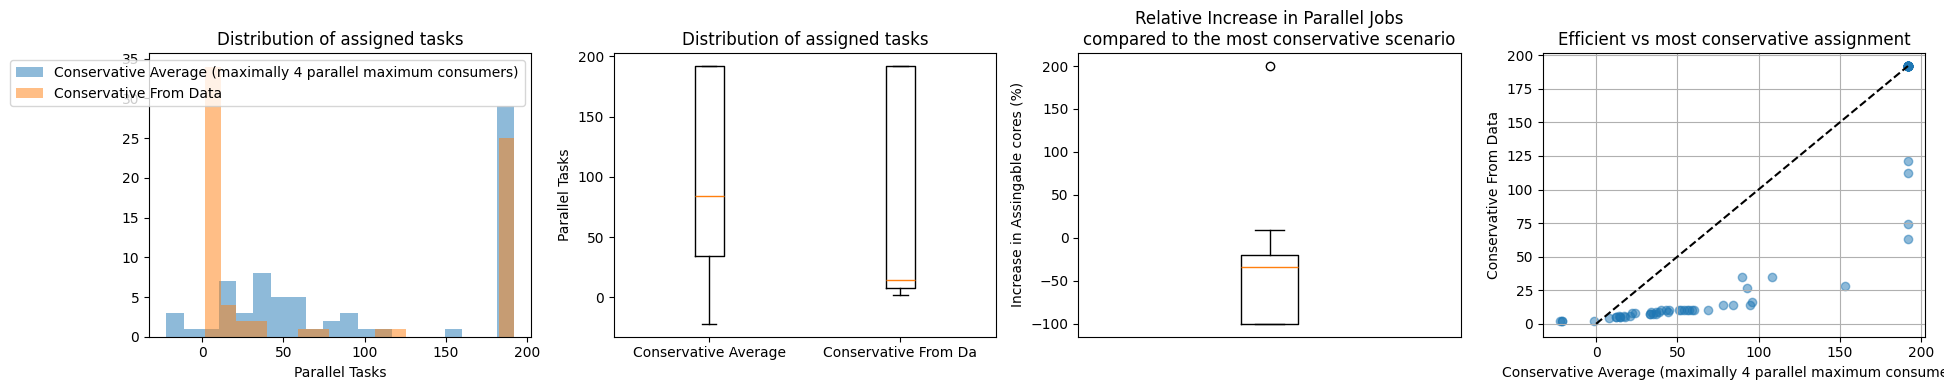

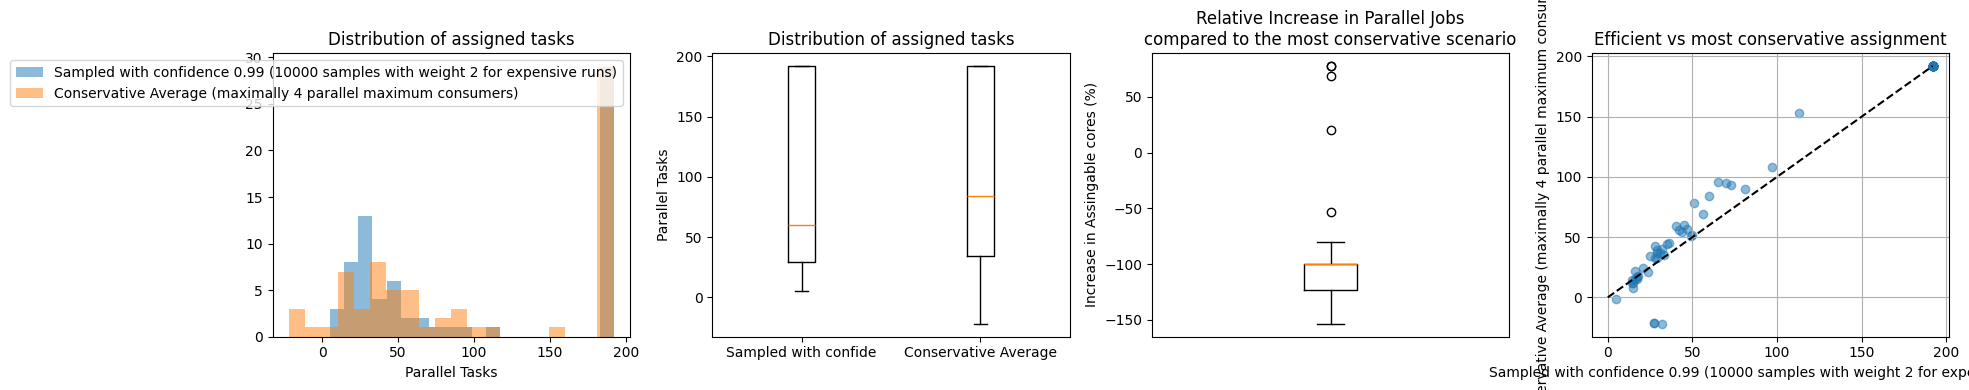

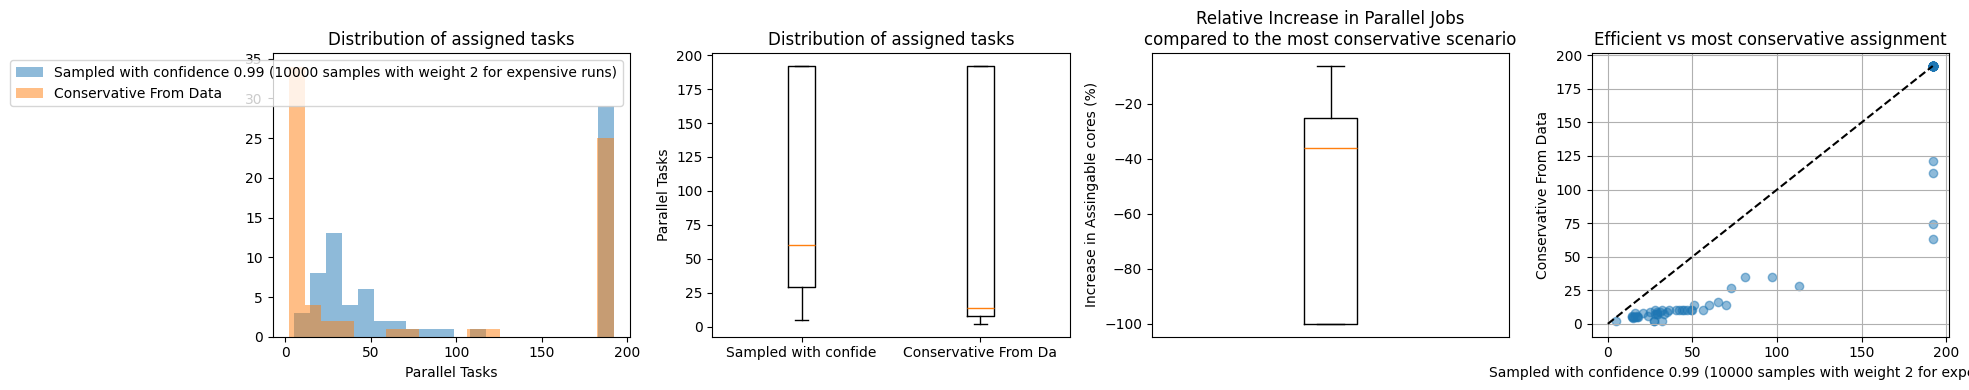

In [13]:
for estimator in [estimator_64, estimator_128]:
    compare_task_parallelization_for_schemes(estimator, "conservative_from_data_True", "most_conservative", 192)
    compare_task_parallelization_for_schemes(estimator, "conservative_average_4_True", "conservative_from_data_True", 192)
    compare_task_parallelization_for_schemes(estimator, "sampled_10000_0.99_2", "conservative_average_4_True", 192)
    compare_task_parallelization_for_schemes(estimator, "sampled_10000_0.99_2", "conservative_from_data_True", 192)

# Temporary: Assign to all Workflows the same as needed by KNN

In [14]:
df_others = df.copy()
df_others = df_others.drop(columns="workflow")
df_others["memory_peaks"] = [r.copy() for r in df_others["memory_peaks"]]
df_others["memory_peaks"] *= 2
df_others["memory mean peak"] *= 2
df_others["memory max peak"] *= 2
df_others["memory max foreseen peak"] *= 2
estimator_others_64 = TaskParallelizationEstimator(df_others, absolute_memory_limit_per_node=336, absolute_memory_limit_per_config=64)
estimator_others_64.approximate_parallel_tasks_based_on_sampling(confidence=0.99, sample_size=10**4, importance_of_most_expensive_compared_to_cheapest=2)
estimator_others_128 = TaskParallelizationEstimator(df_others, absolute_memory_limit_per_node=336, absolute_memory_limit_per_config=128)
estimator_others_128.approximate_parallel_tasks_based_on_sampling(confidence=0.99, sample_size=10**4, importance_of_most_expensive_compared_to_cheapest=2)

100%|██████████| 71/71 [18:54<00:00, 15.97s/it]


In [16]:
for limit, estimator in zip([64, 128], [estimator_others_64, estimator_others_128]):
    df_assignments_tentative_complete = [pd.read_csv(f"resource_assignments_{limit}gb_limit_knn.csv")]
    for workflow in [
        "lcdb.workflow.sklearn.LibLinearWorkflow",
        "lcdb.workflow.sklearn.LibSVMWorkflow",
        "lcdb.workflow.sklearn.TreesEnsembleWorkflow",
        "lcdb.workflow.xgboost.XGBoostWorkflow"
    ]:
        df_assignment_workflow = estimator.get_profile_df(
            profile="sampled_10000_0.99_2",
            available_cpus=192
        )
        df_assignment_workflow["workflow"] = workflow
        df_assignments_tentative_complete.append(df_assignment_workflow)
            
        
    df_full = pd.concat(df_assignments_tentative_complete)
    df_full.to_csv(f"resource_assignments_{limit}gb_limit.csv", index=False)
    df_full